# التحويلات المورفولوجية:
###  الهدف:
في هذا الفصل سنتعلم عمليات مورفولوجية مختلفة مثل 
**Erosion , Dilation**
والفتح والاغلاق
وسنرى توابع مختلفة مثل:
`cv2.erode` , `cv2.dilate` , `cv2.morphologyEx`

##  النظرية:
التحويلات المورفولوجية , هي عمليات بسيطة على الصور الثنائية عادة , ولها دخلين هما الصورة الاصلية  والعنصر التركيبي الذي يحدد طبيعة العملية والعمليات الاساسية هي 
**Erosion , Dilation**
 ثم يأتي بعدها كتركيب لها , الفتح والاغلاق والتدرج
 وسنطبق ما سبق ,واحدا عقب الاخر على الصورة التالية

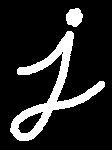

In [2]:
from IPython.display import Image
Image('j.png')

###  Erosion
هذا التحويل يحاول تنعيم سطح الامامية , التي دائما بيضاء , وذلك بجعل قيمة العنصر 1 فقط في حالة العناصر المحيطة به كلها كذلك تحت القناع
`1`
وبذلك بالاعتماد على حجم القناع تتحدد الثخانة للناتج , وهذا يفيد بازالة الضجيج كالنقاط البيضاء الصغيرة او فصل جسمين متصلين خطأً, والتالي يبين قناعاً كله واحدات يطبق ما سبق

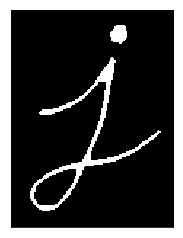

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('j.png',0)
kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)

plt.imshow(erosion,cmap = 'gray')
plt.xticks([]) , plt.yticks([]) , plt.show()
None

### Dilation
وهذا يقابل السابق , فهنا البكسل يأخذ القيمة 1 اذا كان واحد من عناصره تحت القناع 1 على الاقل, وهكذا فهو يزيد حجم المنطقة البيضاء , وبالعادة بالحالات الخاصة بازالة الضجيج يتبع هذا ال
**Erosion **
لان الاخير يزيل الضجيج ولكنه ايضاً يقلل مساحة الجسم , ولذلك نطبق التحويل
**Dilation**

وهو يفيد ايضاً بجمع اجزاء الجسم المتكسرة , كالتالي:

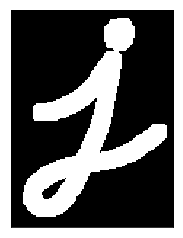

In [4]:
dilation = cv2.dilate(img,kernel,iterations = 1)

plt.imshow(dilation,cmap = 'gray')
plt.xticks([]) , plt.yticks([]) , plt.show()
None

### الفتح:
الفتح هو اسم اخر لتطبيق
**Erosion ,then ,Dilation**
وهذا يفيد بازالة الضجيج كما شرحنا اعلاه , ويتم عبر التابع
`cv2.morphologyEx`

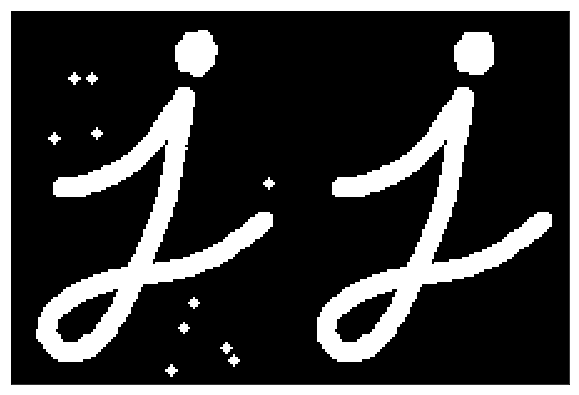

In [5]:
import random
h , w = img.shape
# add noise
for x in range(15):
    cv2.circle(img,(random.randint(0,w),random.randint(0,h)),2,
              (255,255,255),-1)
    
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
plt.figure(figsize=[10,10])
res = np.hstack([img,opening])
plt.imshow(res,cmap = 'gray')
plt.xticks([]) , plt.yticks([]) , plt.show()
None

###  الاغلاق:
وهو عكس الفتح , اي 
**Dilation ,then , Erosion**
وهو يفيد باغلاق الثقوب السوداء في الجسم , او النقاط السوداء

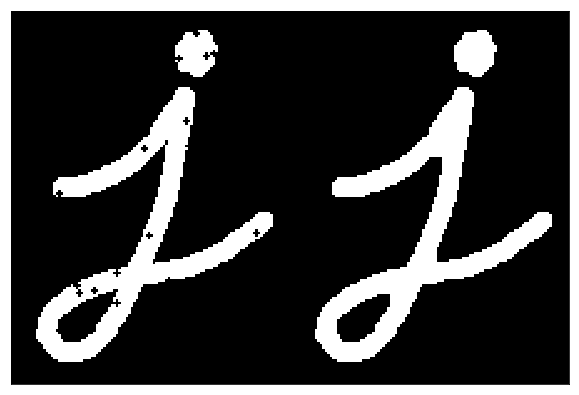

In [6]:
img = cv2.imread('j.png',0)

# add noise
for x in range(100):
    cv2.circle(img,(random.randint(0,w),random.randint(0,h)),1,
              (0,0,0),-1)
    
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
plt.figure(figsize=[10,10])
res = np.hstack([img,closing])
plt.imshow(res,cmap = 'gray')
plt.xticks([]) , plt.yticks([]) , plt.show()
None

###  التدرج الموفولوجي:
وهو الفرق بين ال
**Dilation and the Erosion**
لصورة , والنتيجة ستبدو كحدود للجسم ,كالتالي

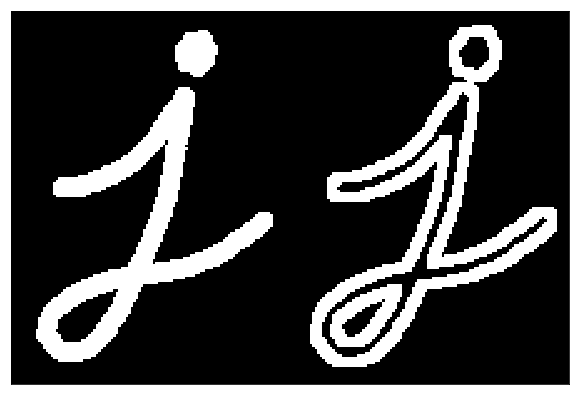

In [8]:
img = cv2.imread('j.png',0)
   
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)
plt.figure(figsize=[10,10])
res = np.hstack([img,gradient])
plt.imshow(res,cmap = 'gray')
plt.xticks([]) , plt.yticks([]) , plt.show()
None

### قبعة القمة:
وهو الفرق بين فتح الصورة والصورة نفسها , وفيما يلي تطبيق له من اجل قناع`9,9` كالتالي

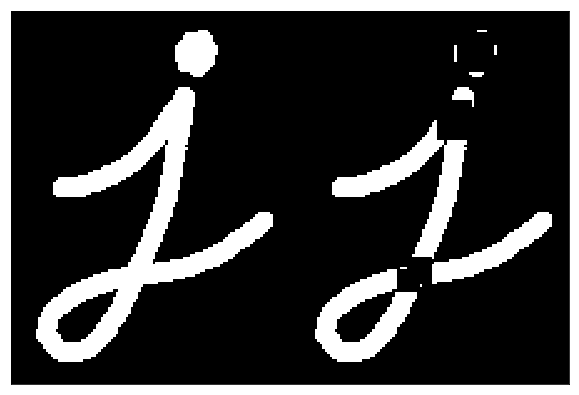

In [10]:
kernel = np.ones((9,9),np.uint8)

tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
plt.figure(figsize=[10,10])
res = np.hstack([img,tophat])
plt.imshow(res,cmap = 'gray')
plt.xticks([]) , plt.yticks([]) , plt.show()
None

###  القبعة السوداء:
وهو الفرق بين اغلاق صورة الدخل وصورة الدخل , كالتالي:

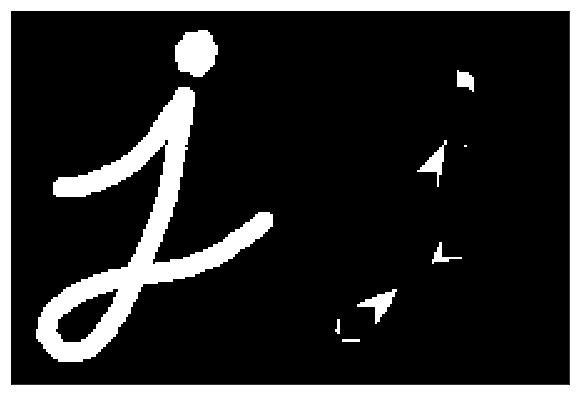

In [11]:
kernel = np.ones((9,9),np.uint8)

blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)
plt.figure(figsize=[10,10])
res = np.hstack([img,blackhat])
plt.imshow(res,cmap = 'gray')
plt.xticks([]) , plt.yticks([]) , plt.show()
None

###  العنصر التركيبي:
انشأنا سابقا عنصرا تركيبيا يدويا بمساعدة 
**Numpy**
وكان مستطيل الشكل ولكن احيانا تحتاج , اشكال اخرى كالدائري والقطعي , ولهذا الغرض كان التابع
`cv2.getStructuringElement`
وعند تمرير نوع العنصر وحجمه له , يعطينا العنصر المطلوب

In [15]:
# Rectangular Kernel
cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [16]:
# Elliptical Kernel
cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))

array([[0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0]], dtype=uint8)

In [14]:
# Cross-shaped Kernel
cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5))

array([[0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0],
       [1, 1, 1, 1, 1],
       [0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0]], dtype=uint8)

# ميول الصورة:

###  الهدف:
سنتعلم بهذا الفصل , ايجاد ميول الصورة والحواف , الخ ..
وسنرى التوابع التالية:
`cv2.Sobel` , `cv2.Scharr` , `cv2.Laplacian`

##  النظرية
يقدم
**OpenCV**
ثلاث انواع من مرشحات التدرج أو التمرير العالي , وهي 
`Sobel` , `Scharr` , `Laplacian`
وسنرى كلا منهم 

###  أولا : مشتقاتSobel & Scharr :

معاملات سوبول , هي دمج للتنعيم الغاوسي و العمليات التفاضلية , ولهذا هو مقاوم اكثر للضجيج , ويمكنك ان تحدد اتجاه الاشتقاق (افقي او عامودي) من خلال المداخيل , ويمكنك ايضاً تحديد حجم القناع من خلال المتغير في الدخل , واذا مررت `-1` كحجم , فسيستخدم قناع 
`3,3`
وسيكون بنوع
`Scharr`
والذي يعطي نتائج افضل .بامكانك مراجعة التوثيق الاصلي لها

### ثانيا : مشتقات لابلاس:

انه يحسب , لابلاسيان الصورة وذلك من خلال تطبيق الاقنعة المناسبة مثلاً اذا كان القياس `1` سيكون القناع كالتالي

In [17]:
np.array([[0,1,0],[1,-4,1],[0,1,0]])

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

###  برنامج:
المثال التالي يوضح كل ماسبق بمخطط واحد , وكل الاقنعة بقياس 
`5,5`
وكذلك عنق صورة الخرج يمرر ك `-1` للحصول على ناتج بصيغة
`np.uint8`

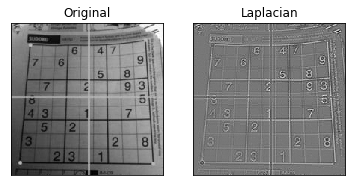

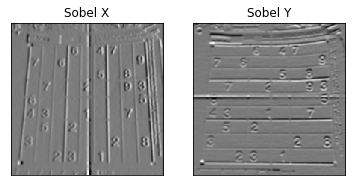

In [18]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('sudokusmall.bmp',0)
laplacian = cv2.Laplacian(img,cv2.CV_64F)
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=5)

plt.subplot(1,2,1),plt.imshow(img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2),plt.imshow(laplacian,cmap = 'gray')
plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
plt.show()

plt.subplot(1,2,1),plt.imshow(sobelx,cmap = 'gray')
plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2),plt.imshow(sobely,cmap = 'gray')
plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])

plt.show()

## قضية مهمة أخيرة:

في مثالنا الاخير , نوع الصورة كان
`np.uint8` or `cv2.CV_8U`

ولكن هناك فرق , فعند التحويل من النوع الاول للثاني , تكون الحواف ذات الانتقال من الاسود للابيض بقيمة موجبة اما العكس فبقيمة سالبة , ولذلك , عند تحويل الصيغة نفقد تلك الحواف لانها تعتبر اصفاراً .

اذا اردت اكتشاف كل من الحواف فما عليك , الا الابقاء عليها بصيغة مكبرة , ومن ثم اخذ القيمة المطلقة لها , وثم تحويلها للصيغة الملائمة للاظهار والتالي يوضح الفكرة ويبين الخطأ الحاصل بالحالة الاولى


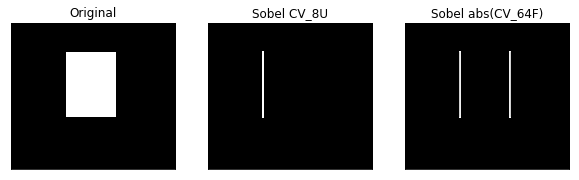

In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('box.png',0)

# Output dtype = cv2.CV_8U
sobelx8u = cv2.Sobel(img,cv2.CV_8U,1,0,ksize=5)

# Output dtype = cv2.CV_64F. Then take its absolute and
# convert to cv2.CV_8U
sobelx64f = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5)
abs_sobel64f = np.absolute(sobelx64f)
sobel_8u = np.uint8(abs_sobel64f)

plt.figure(figsize=[10,10])
plt.subplot(1,3,1),plt.imshow(img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,2),plt.imshow(sobelx8u,cmap = 'gray')
plt.title('Sobel CV_8U'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,3),plt.imshow(sobel_8u,cmap = 'gray')
plt.title('Sobel abs(CV_64F)'), plt.xticks([]), plt.yticks([])

plt.show()